In [4]:
import pandas as pd
import seaborn as sns

In [32]:
df = pd.read_excel(r"C:\Users\amare\OneDrive\Desktop\Crime Hotspots Capstone Project\crime-hotspot-prediction-project\data\05_model_input\master_dataset_knn_train.xlsx")

In [33]:
df

,Cluster,Crime Count,population_density,poor_households,population_unemployment,population_education,crime_type_ Abduction,crime_type_ All theft not mentioned elsewhere,crime_type_ Arson,crime_type_ Assault with the intent to inflict bodily harm,...,crime_type_ Sexual Offences (also see SDS),crime_type_ Sexual Offences detected as a result of police action,crime_type_ Shoplifting,crime_type_ Stock theft,crime_type_ Street public robbery,crime_type_ TRIO Crimes,crime_type_ Theft of motor vehicle and motorcycle,crime_type_ Theft out of or from motor vehicle,crime_type_ Truck hijacking,year
0,0,1.701491,-2.044934,-2.021910,-1.427107,0.983035,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1.591369
1,0,1.701491,-2.044934,-2.021910,-1.427107,0.990569,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1.591369
2,0,1.701491,-2.044934,-2.021910,-1.427107,0.975873,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1.591369
3,0,1.701491,-2.044934,-2.021910,-1.427107,0.927051,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1.591369
4,0,1.701491,-2.044934,-2.021910,-1.427107,0.840799,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1.591369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
624439,9,-0.417598,0.560050,0.680023,0.704050,-1.542859,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.591099
624440,9,-0.417598,0.560050,0.680023,0.704050,-1.634405,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.591099
624441,9,-0.417598,0.560050,0.680023,0.704050,-1.357885,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.591099
624442,9,-0.417598,0.560050,0.680023,0.704050,-1.564082,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.591099


<Axes: xlabel='Crime Count', ylabel='Count'>

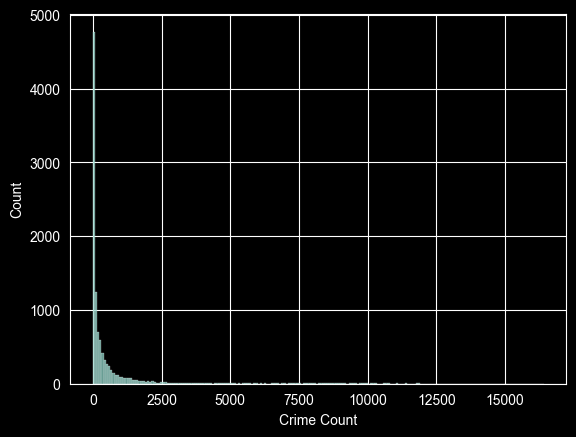

In [5]:
sns.histplot(df, x = "Crime Count")

In [8]:
# scale for KNN then leave as if for tree based models
import numpy as np
import sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df["log_Crime Count"] = np.log1p(df["Crime Count"])
df["crime_scaled"] = scaler.fit_transform(df[["log_Crime Count"]])

SyntaxError: invalid syntax (3615140958.py, line 3)

In [6]:
# total number of elements in Cluster column/ Class Balance
df.groupby("Cluster").size().sort_values(ascending=False)

Cluster
Polokwane      159494
Tzaneen         83475
Makhado         83104
Mahwelereng     81885
Burgersfort     81355
Giyani          80878
Lephalale       79553
Groblersdal     79394
Modimolle       77963
Bela Bela       73935
dtype: int64

In [ ]:
# --- Lag features (previous year values per Cluster) ---
lag_cols = ["Crime Count", "population_density", "population_unemployment", "poor_households"]
for col in lag_cols:
    df[f"{col}_lag1"] = df.groupby("Cluster")[col].shift(1)
    df[f"{col}_lag2"] = df.groupby("Cluster")[col].shift(2)

# --- Rolling statistics (3-year window per Cluster) ---
for col in lag_cols:
    df[f"{col}_rolling_mean_3"] = (
        df.groupby("Cluster")[col]
        .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
    )
    df[f"{col}_rolling_std_3"] = (
        df.groupby("Cluster")[col]
        .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).std())
    )

# --- Year-over-year change ---
for col in lag_cols:
    df[f"{col}_yoy_change"] = df.groupby("Cluster")[col].pct_change()
